In [1]:
import pandas as pd
import numpy as np
import pingouin as pg
import matplotlib.pyplot as plt
import seaborn as sns

# <u><b> Data Importing and Cleaning <b><u>

In [2]:
df = pd.read_excel("C:/Users/Adity/Desktop/Aditya/Projects/Sugar Cosmetics/sugar cosmetics.xlsx")

In [3]:
# df.drop(columns = ['hashtags'], inplace = True)
# df.head()

In [4]:
# df.to_csv("C:/Users/Adity/Desktop/Aditya/Projects/Sugar Cosmetics/sugar cosmetics.csv", index = False)

In [5]:
df['Hashtags'] = df["Hashtags"].str.replace('"', "")

In [6]:
df.rename(columns = {'Post_ID': 'Post Id'}, inplace = True)
df.head()

,Post Id,Post Date,Post Type,Campaign Type,Hashtags,Audience Emotion,Engagement Source,Impressions,Reach,Likes,Comments,Shares,Saves,Profile Visits,Follows,Hashtag Counts,Engagement_Rate,Day of the Week,Name DOW
0,1,2024-04-19,Image,Festive Offer,#SugarCosmetics,Happy,Organic,41908,38733,6519,646,186,261,1916,663,1,0.1965,6,Saturday
1,2,2024-04-19,Reel,Giveaway,#BoldLooks,Happy,Influencer,30587,19460,3873,434,339,105,907,294,1,0.2441,6,Saturday
2,3,2024-04-19,Reel,Festive Offer,"#CrueltyFree, #VeganBeauty",Confident,Organic,3968,3146,394,25,21,39,102,24,2,0.1523,6,Saturday
3,4,2024-04-19,Story,Influencer Collab,"#MakeupGoals, #CrueltyFree, #BoldLooks",Excited,Collab,25621,16907,1307,237,101,33,250,100,3,0.0992,6,Saturday
4,5,2024-04-19,Story,Festive Offer,"#VeganBeauty, #BoldLooks, #MakeupGoals",Inspired,Collab,41546,38835,2394,424,51,228,794,153,3,0.0797,6,Saturday


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Post Id            50000 non-null  int64         
 1   Post Date          50000 non-null  datetime64[ns]
 2   Post Type          50000 non-null  object        
 3   Campaign Type      50000 non-null  object        
 4   Hashtags           50000 non-null  object        
 5   Audience Emotion   50000 non-null  object        
 6   Engagement Source  50000 non-null  object        
 7   Impressions        50000 non-null  int64         
 8   Reach              50000 non-null  int64         
 9   Likes              50000 non-null  int64         
 10  Comments           50000 non-null  int64         
 11  Shares             50000 non-null  int64         
 12  Saves              50000 non-null  int64         
 13  Profile Visits     50000 non-null  int64         
 14  Follow

# <u><b> Data Normalization <b><u>

### Dim Table: Hashtag Table

In [8]:
hashtags = df['Hashtags'].str.split(",").explode().str.strip().dropna().unique()
hashtags

dim_hashtags = pd.DataFrame(hashtags, columns = ['hashtags'])
dim_hashtags['hashtag_id'] = range(1, len(hashtags) + 1)
dim_hashtags

,hashtags,hashtag_id
0,#SugarCosmetics,1
1,#BoldLooks,2
2,#CrueltyFree,3
3,#VeganBeauty,4
4,#MakeupGoals,5


### Dim Table: Post Type Table

In [9]:
post_type = df['Post Type'].unique()
dim_post_type = pd.DataFrame(post_type, columns = ['post_type'])
dim_post_type['post_type_id'] = range(1, len(post_type) +1)
dim_post_type

,post_type,post_type_id
0,Image,1
1,Reel,2
2,Story,3
3,Video,4


### Dim Table: Campaign Type

In [10]:
campaign = df['Campaign Type'].unique()
dim_campaign_type = pd.DataFrame(campaign, columns = ['campaign_type'])
dim_campaign_type['campaign_id'] = range(1, len(campaign) + 1)
dim_campaign_type

,campaign_type,campaign_id
0,Festive Offer,1
1,Giveaway,2
2,Influencer Collab,3
3,Tutorial,4
4,Product Launch,5


### Dim Table: Audience Emotions

In [11]:
audience = df['Audience Emotion'].unique()
dim_audience_emotion = pd.DataFrame(audience, columns = ['audience_emotion'])
dim_audience_emotion['emotion_id'] = range(1, len(audience) + 1)
dim_audience_emotion 

,audience_emotion,emotion_id
0,Happy,1
1,Confident,2
2,Excited,3
3,Inspired,4
4,Curious,5


### Dim Table: Engagement Source 

In [12]:
engagement = df['Engagement Source'].unique()
dim_engagement_source = pd.DataFrame(engagement, columns = ['engagement_source'])
dim_engagement_source['engagement_id'] = range(1, len(engagement) + 1)
dim_engagement_source

,engagement_source,engagement_id
0,Organic,1
1,Influencer,2
2,Collab,3
3,Paid,4


### Dim Table: Date Table 

In [13]:
dim_date = pd.DataFrame({'Date' : pd.date_range(df['Post Date'].min(), df['Post Date'].max(), freq = 'D')}) 
dim_date['year'] = dim_date['Date'].dt.year
dim_date['quarter'] = dim_date['Date'].dt.quarter
dim_date['month'] = dim_date['Date'].dt.month
dim_date['dow'] = dim_date['Date'].dt.dayofweek + 1
dim_date['is_weekend'] = dim_date['dow'].isin([6, 7])
dim_date

,Date,year,quarter,month,dow,is_weekend
0,2024-04-19,2024,2,4,5,False
1,2024-04-20,2024,2,4,6,True
2,2024-04-21,2024,2,4,7,True
3,2024-04-22,2024,2,4,1,False
4,2024-04-23,2024,2,4,2,False
...,...,...,...,...,...,...
361,2025-04-15,2025,2,4,2,False
362,2025-04-16,2025,2,4,3,False
363,2025-04-17,2025,2,4,4,False
364,2025-04-18,2025,2,4,5,False


### Bridge Table : Post ID - Hashtag ID

In [14]:
bt = df[['Post Id', 'Hashtags']].copy()

bt['Hashtags'] = bt['Hashtags'].str.split(',')

bt = bt.explode('Hashtags')

bt['Hashtags'] = bt['Hashtags'].str.strip()

bt.head()

,Post Id,Hashtags
0,1,#SugarCosmetics
1,2,#BoldLooks
2,3,#CrueltyFree
2,3,#VeganBeauty
3,4,#MakeupGoals


In [15]:
# Continuation
new_bt = bt.copy()
new_bt = bt.merge(dim_hashtags, left_on = "Hashtags", right_on = 'hashtags', how = 'left')
new_bt = new_bt[["Post Id", "hashtag_id"]]
bt = new_bt

In [16]:
bt.head()

,Post Id,hashtag_id
0,1,1
1,2,2
2,3,3
3,3,4
4,4,5


In [17]:
columns = [
    "Post Id", "Date", "post_type_id", "campaign_id", "emotion_id", "engagement_id", 
    "Impressions", "Reach", "Likes", "Comments", "Shares", "Saves", "Profile Visits", "Follows", 
    "Hashtag Counts", "Engagement_Rate"
]

print(columns)

['Post Id', 'Date', 'post_type_id', 'campaign_id', 'emotion_id', 'engagement_id', 'Impressions', 'Reach', 'Likes', 'Comments', 'Shares', 'Saves', 'Profile Visits', 'Follows', 'Hashtag Counts', 'Engagement_Rate']


## Merging the Table and Creating a Normalized DataFrame

In [18]:
fact_df = df.copy()
fact_df = fact_df.merge(dim_post_type, left_on = 'Post Type', right_on = 'post_type' , how = 'left')
fact_df = fact_df.merge(dim_audience_emotion, left_on = 'Audience Emotion', right_on = 'audience_emotion' , how = 'left')
fact_df = fact_df.merge(dim_campaign_type, left_on = 'Campaign Type', right_on = 'campaign_type' , how = 'left')
fact_df = fact_df.merge(dim_engagement_source, left_on = 'Engagement Source', right_on = 'engagement_source' , how = 'left')
fact_df = fact_df.merge(dim_date, left_on = 'Post Date', right_on = 'Date' , how = 'left')

fact_df = fact_df[columns]

# Re-Naming the columns 
fact_df.rename(columns = {"post_type_id": "Post Type Id"}, inplace = True)
fact_df.rename(columns = {"campaign_id": "Campaign Id"}, inplace = True)
fact_df.rename(columns = {"emotion_id": "Emotion Id"}, inplace = True)
fact_df.rename(columns = {"engagement_id": "Engagement Id"}, inplace = True)
fact_df.rename(columns = {"Engagement_Rate": "Engagement Rate"}, inplace = True)

fact_df.head()

,Post Id,Date,Post Type Id,Campaign Id,Emotion Id,Engagement Id,Impressions,Reach,Likes,Comments,Shares,Saves,Profile Visits,Follows,Hashtag Counts,Engagement Rate
0,1,2024-04-19,1,1,1,1,41908,38733,6519,646,186,261,1916,663,1,0.1965
1,2,2024-04-19,2,2,1,2,30587,19460,3873,434,339,105,907,294,1,0.2441
2,3,2024-04-19,2,1,2,1,3968,3146,394,25,21,39,102,24,2,0.1523
3,4,2024-04-19,3,3,3,3,25621,16907,1307,237,101,33,250,100,3,0.0992
4,5,2024-04-19,3,1,4,3,41546,38835,2394,424,51,228,794,153,3,0.0797


In [19]:
fact_df.describe()

,Post Id,Date,Post Type Id,Campaign Id,Emotion Id,Engagement Id,Impressions,Reach,Likes,Comments,Shares,Saves,Profile Visits,Follows,Hashtag Counts,Engagement Rate
count,50000.000000,50000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,2024-10-17 22:51:23.904000256,2.501760,3.001080,3.010640,2.496820,25520.915000,19748.465760,2954.565580,369.187220,162.306760,177.22878,592.695960,177.334200,2.000880,0.185352
min,1.000000,2024-04-19 00:00:00,1.000000,1.000000,1.000000,1.000000,1002.000000,616.000000,40.000000,2.000000,0.000000,1.00000,7.000000,0.000000,1.000000,0.055900
25%,12500.750000,2024-07-18 00:00:00,2.000000,2.000000,2.000000,1.000000,13243.000000,10157.750000,1256.000000,135.000000,50.000000,62.00000,252.000000,63.000000,1.000000,0.123200
50%,25000.500000,2024-10-18 00:00:00,3.000000,3.000000,3.000000,2.000000,25541.000000,19393.500000,2466.000000,282.000000,114.000000,132.00000,497.000000,133.000000,2.000000,0.184900
75%,37500.250000,2025-01-17 00:00:00,3.000000,4.000000,4.000000,3.000000,37758.250000,28763.250000,4255.000000,516.000000,228.000000,246.00000,851.000000,245.000000,3.000000,0.246400
max,50000.000000,2025-04-19 00:00:00,4.000000,5.000000,5.000000,4.000000,49999.000000,47329.000000,11392.000000,2205.000000,1072.000000,1057.00000,2264.000000,1114.000000,3.000000,0.341000
std,14433.901067,NaN,1.115967,1.413067,1.411866,1.115641,14118.653466,11311.962456,2144.918922,311.676485,151.722516,154.94933,428.221806,154.550825,0.816022,0.071957


# <u> Distribution of Engagement Metrics Before and After Outlier Removal (IQR Method) <u>

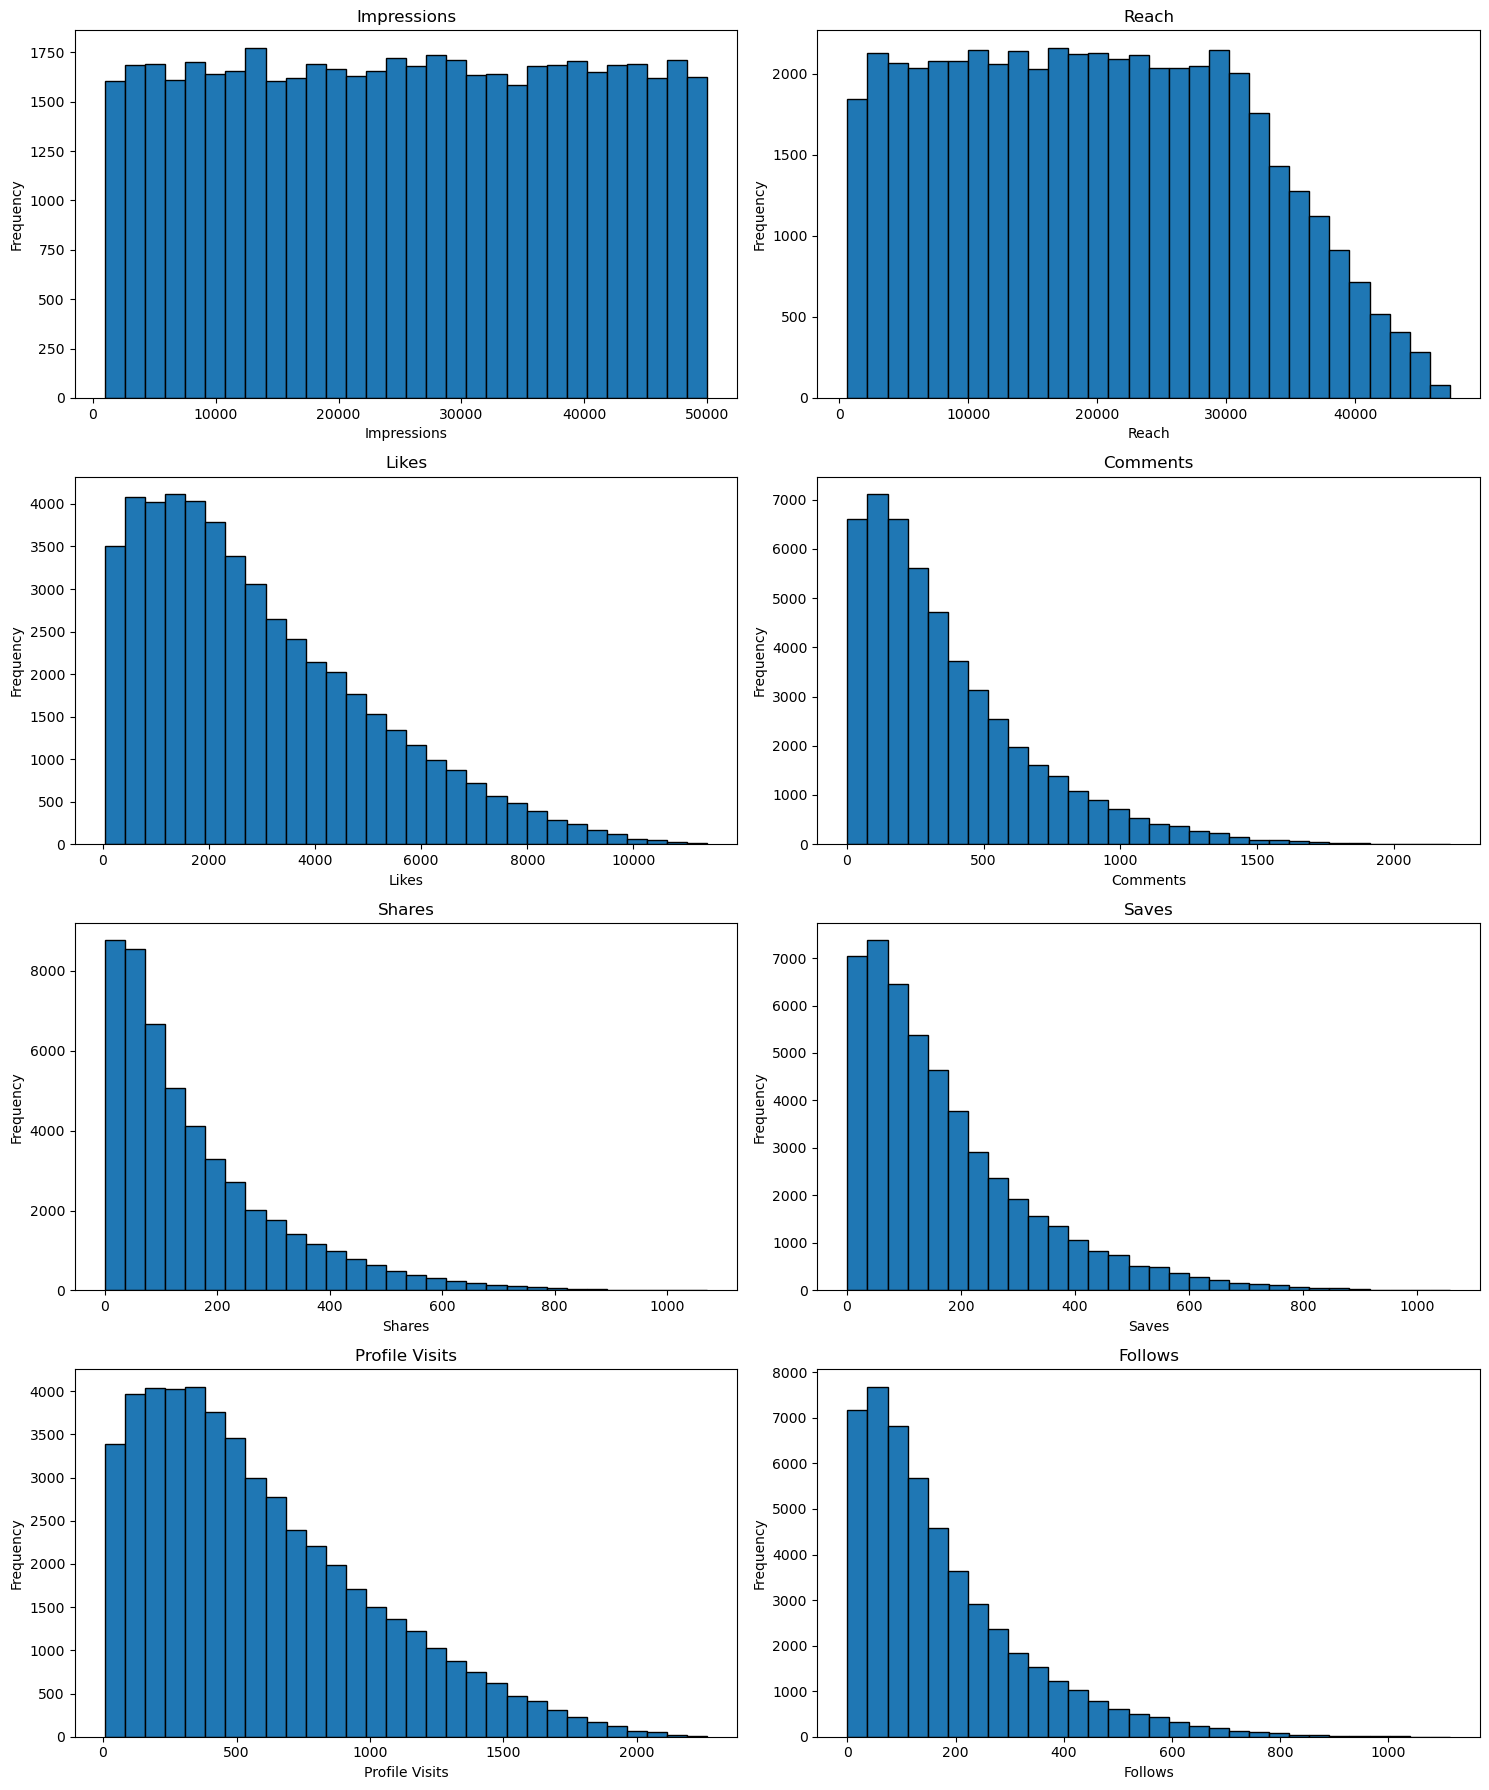

In [20]:
quantitative = ['Impressions', 'Reach', 'Likes', 'Comments', 'Shares', 'Saves', 'Profile Visits', 'Follows']

fig, axes = plt.subplots(4, 2, figsize = (15, 18))
axes = axes.flatten()

for ax, col in zip(axes, quantitative):
    ax.hist(fact_df[col], bins = 30, edgecolor = 'black')
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

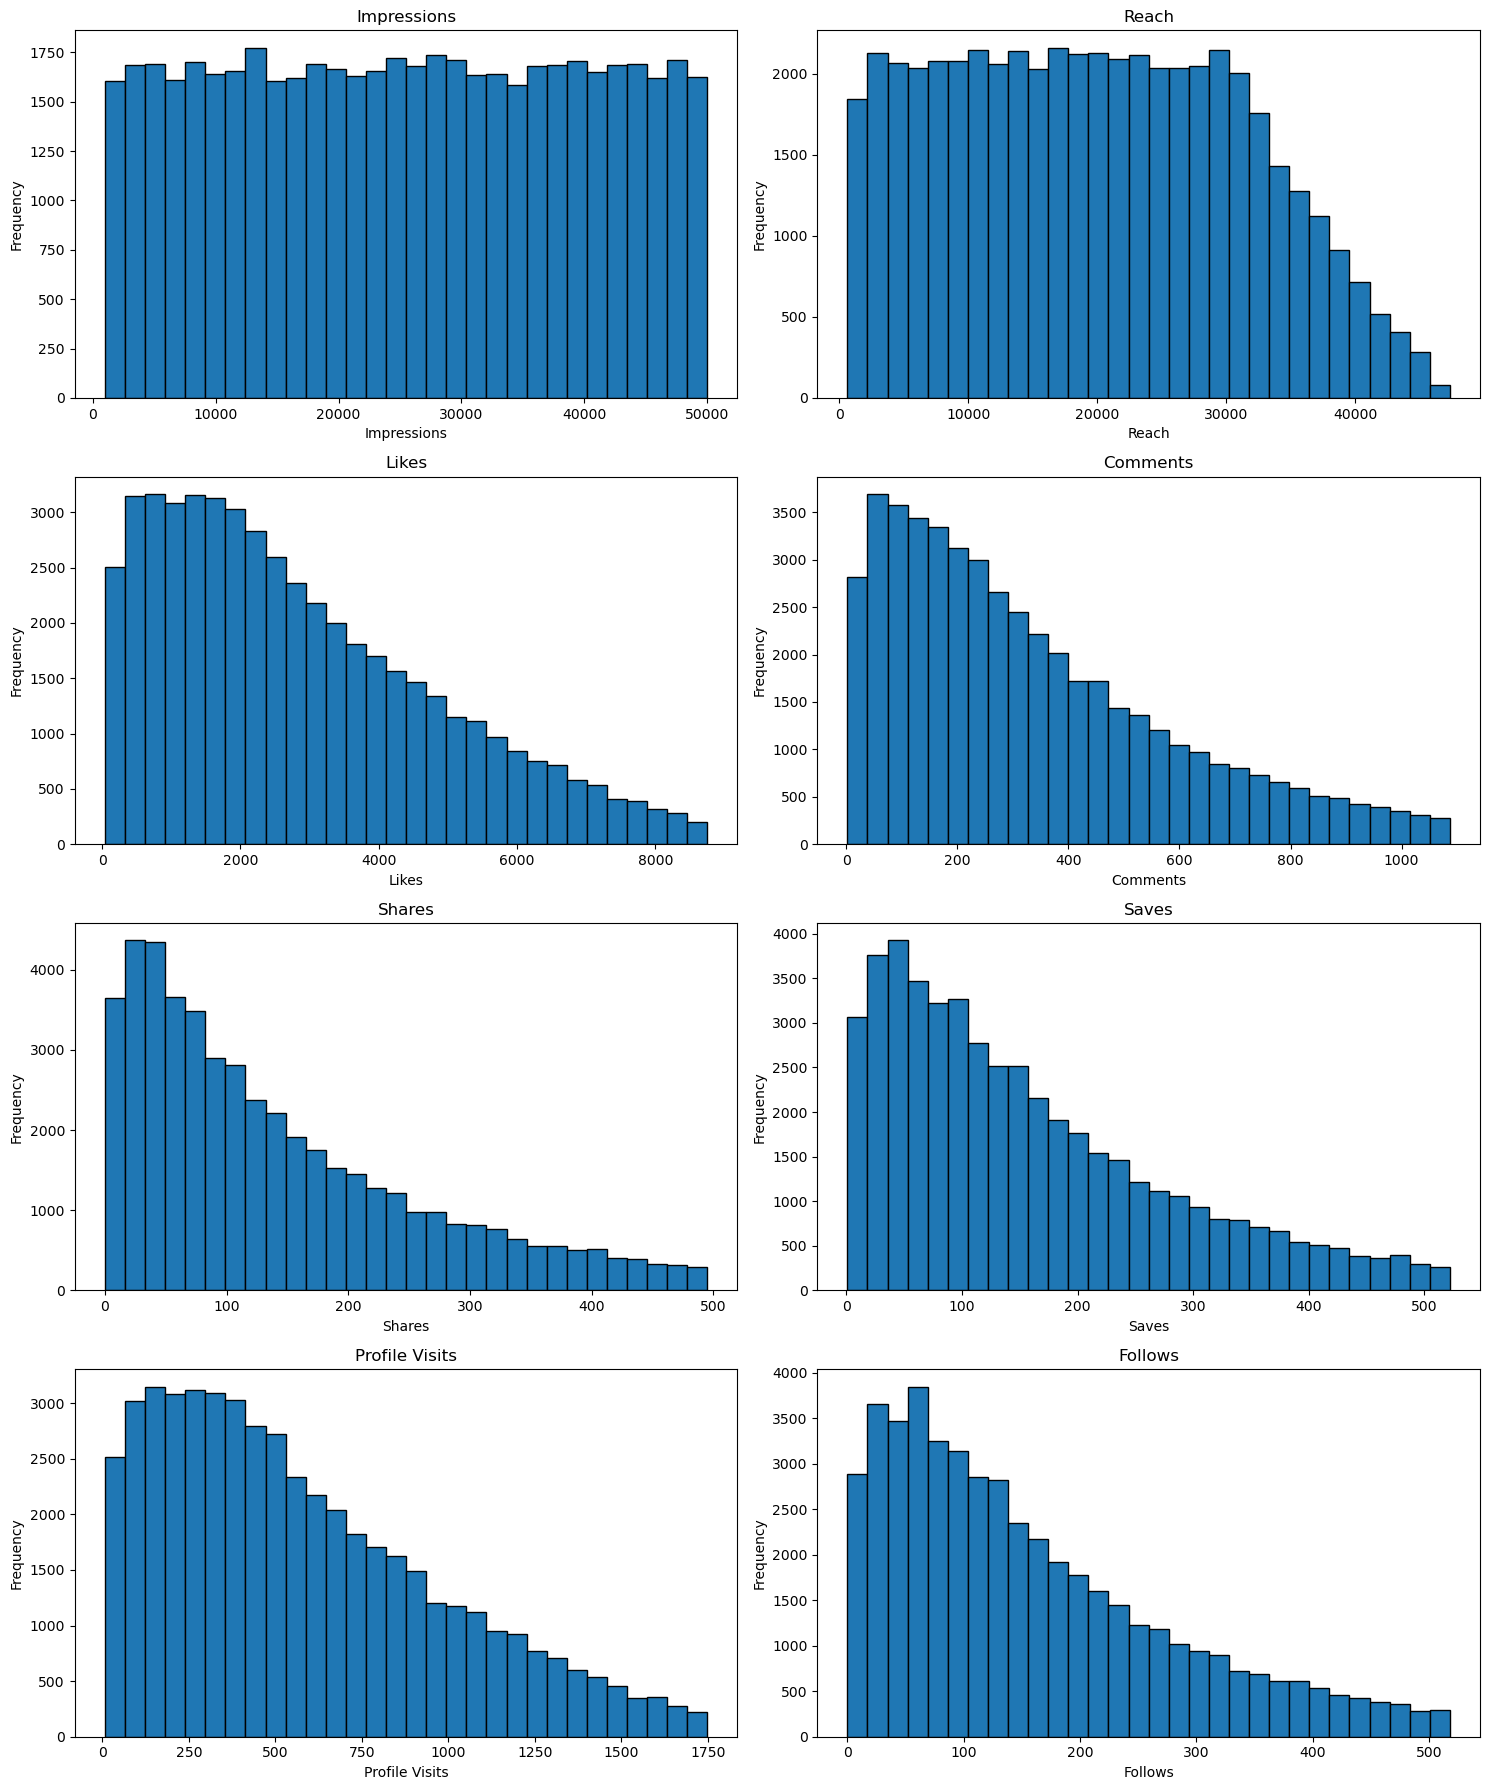

In [21]:
quantitative = ['Impressions', 'Reach', 'Likes', 'Comments', 'Shares', 'Saves', 'Profile Visits', 'Follows']

def iqr_filter(column):
    q1 = fact_df[column].quantile(0.25)
    q3 = fact_df[column].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    return fact_df.loc[
        fact_df[column].between(lower, upper), [column]
    ].reset_index(drop=True)

# Ploting
filtered_dfs = {
    col: iqr_filter(col)
    for col in quantitative
}

fig, axes = plt.subplots(4, 2, figsize=(15, 18))
axes = axes.flatten()

for ax, col in zip(axes, quantitative):
    ax.hist(filtered_dfs[col][col], bins=30, edgecolor='black')
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [22]:
dim_post_type

,post_type,post_type_id
0,Image,1
1,Reel,2
2,Story,3
3,Video,4


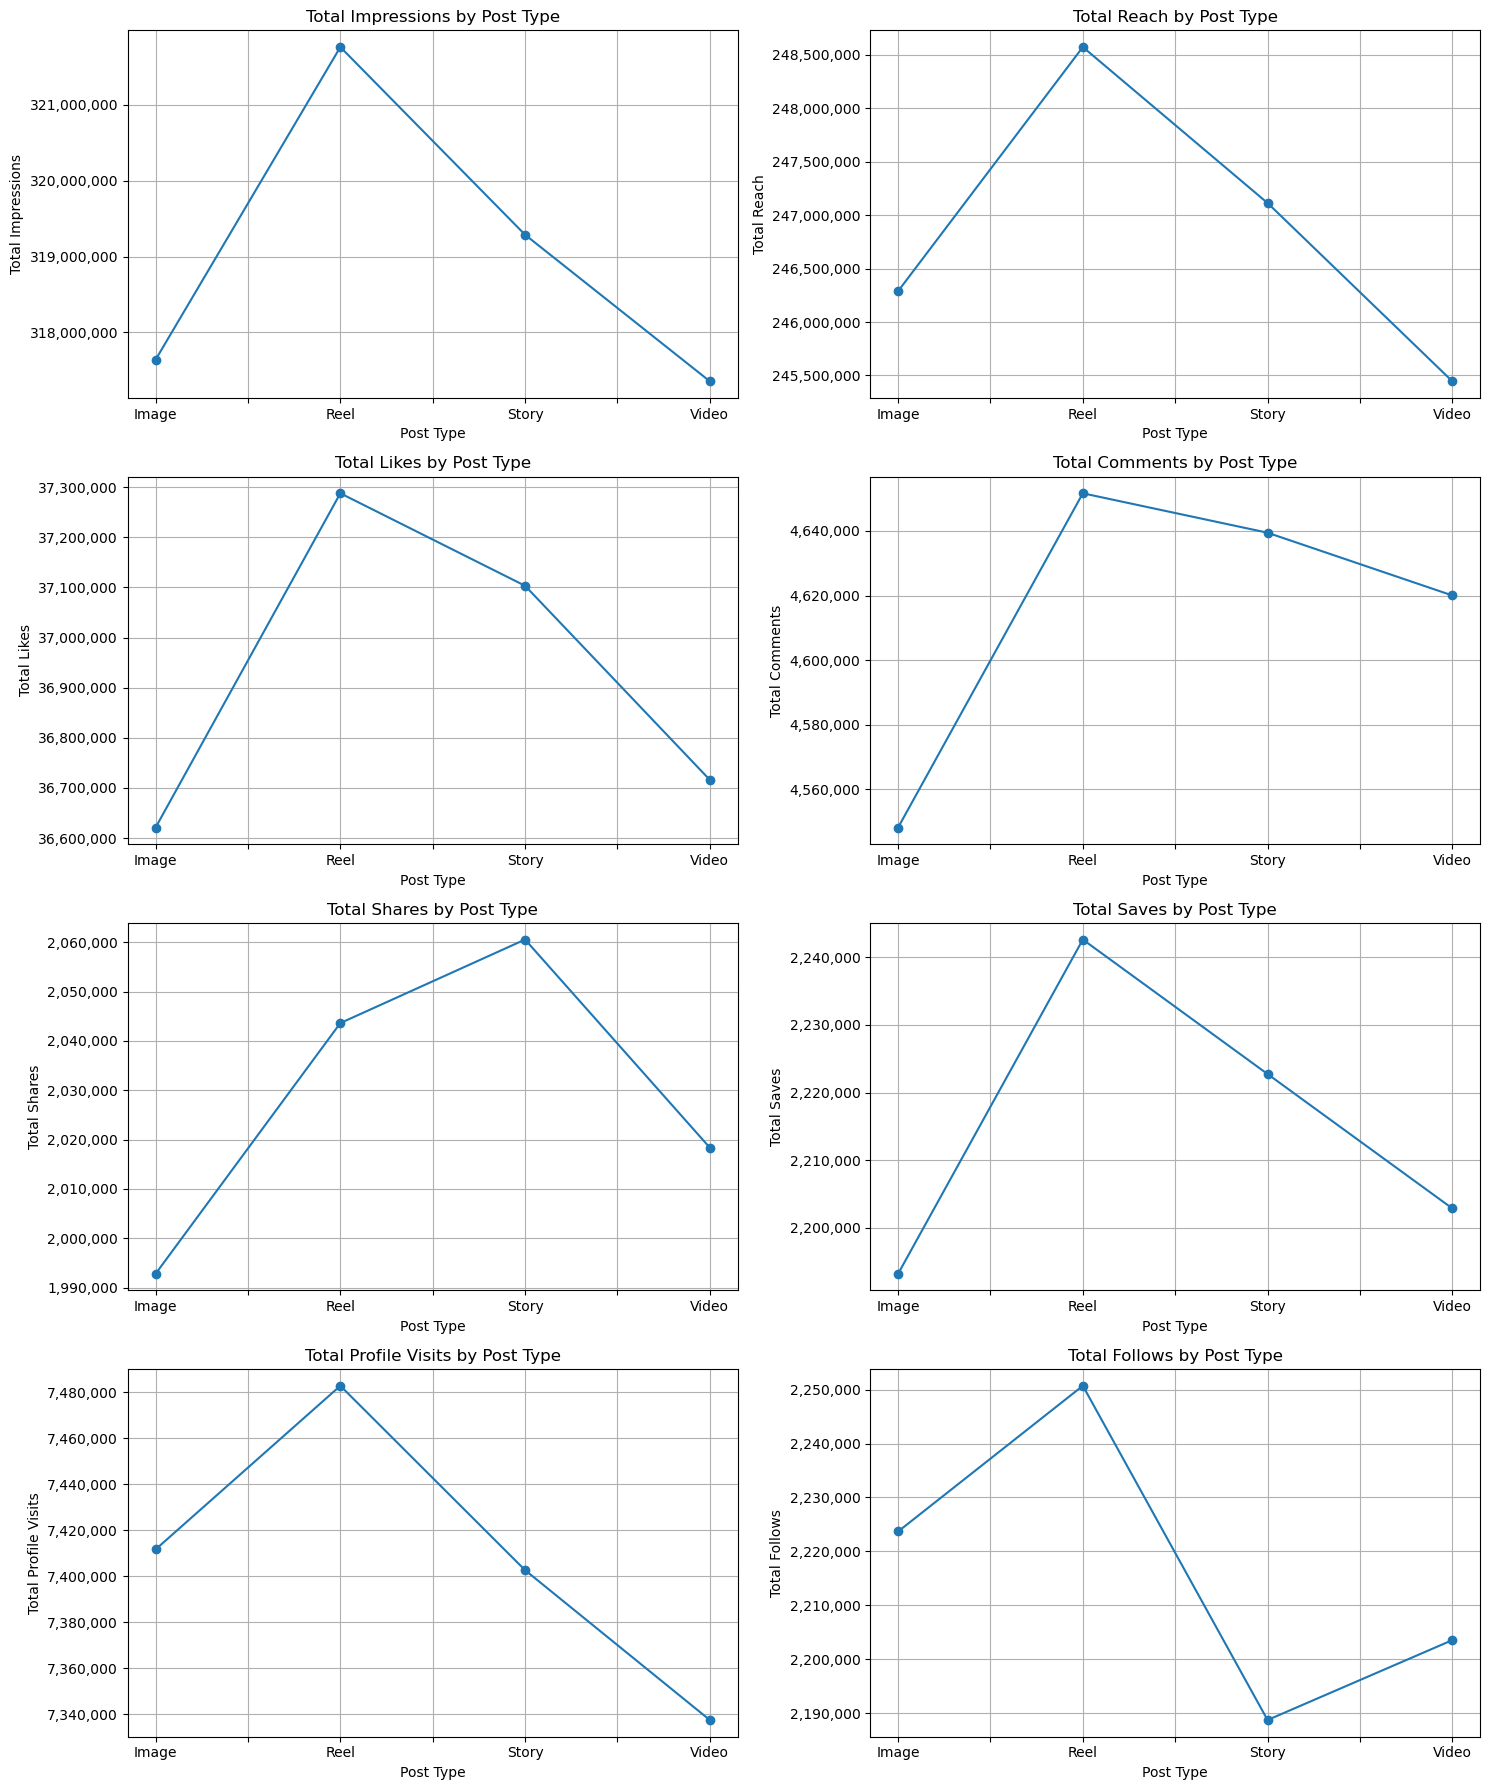

In [23]:
from matplotlib.ticker import StrMethodFormatter

post_type_map = dict(zip(dim_post_type['post_type_id'], dim_post_type['post_type']))
quantitative = ['Impressions', 'Reach', 'Likes', 'Comments', 'Shares', 'Saves', 'Profile Visits', 'Follows']

fig, axes = plt.subplots(4, 2, figsize=(15, 18))
axes = axes.flatten()

for ax, col in zip(axes, quantitative):

    plot_df = fact_df.groupby('Post Type Id')[col].sum()
    plot_df.index = plot_df.index.map(post_type_map)
    
    plot_df.plot(
        kind='line',
        marker='o',
        ax=ax
    )
    
    ax.set_title(f'Total {col} by Post Type')
    ax.set_xlabel('Post Type')
    ax.set_ylabel(f'Total {col}')
    ax.grid(True)
    ax.ticklabel_format(style='plain', axis='y')
    ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

# <u><b> Hypothesis Testing and Statistical Analysis <b><u>

## <u><i> 1. Kruskal–Wallis Test – Examining Differences in Engagement Rate Across Post, Campaign, Emotion, Engagement Types and Hashtag Counts <i><u>

### Null Hypothesis (H₀): There is no statistically significant difference in engagement rates across the categories of Post Type ID, Campaign ID, Emotion ID, Engagement ID, and Hashtag Counts. The distribution (or median) of engagement rates remains the same across all groups within each categorical variable.

### Alternative Hypothesis (H₁): There is a statistically significant difference in engagement rates across the categories of Post Type ID, Campaign ID, Emotion ID, Engagement ID, and Hashtag Counts. At least one group within a categorical variable has a different engagement rate distribution (or median) compared to the others.

In [24]:
columns = ['Post Type Id', 'Campaign Id', 'Emotion Id', 'Engagement Id', 'Hashtag Counts']
def single_kruskal(data, dv, between):
    results = []
    for n in between:
        output = pg.kruskal(data = data, dv = dv, between = n)
        
        results.append(output)
    result = pd.concat(results, ignore_index = True)
    result['Conclusion'] = np.where(result['p_unc'] < 0.10, 'Reject', 'Fail to Reject')
    return result.sort_values(by = 'p_unc').reset_index(drop = True)

tests = single_kruskal(fact_df, 'Engagement Rate', columns)
tests

,Source,ddof1,H,p_unc,Conclusion
0,Hashtag Counts,2,5.725906,0.057100,Reject
1,Post Type Id,3,5.072633,0.166555,Fail to Reject
2,Engagement Id,3,3.191016,0.363101,Fail to Reject
3,Campaign Id,4,3.648936,0.455596,Fail to Reject
4,Emotion Id,4,2.917095,0.571794,Fail to Reject


## <U> Kruskal–Wallis Test: Engagement Rate Across Hashtag Count Categories <U>

### A Kruskal–Wallis H test was conducted to determine whether engagement rates differed across hashtag count categories. The results indicated a statistically significant difference in engagement rates among the hashtag count groups, H(2) = 5.726, p = 0.057.

### Using a significance level of 10% (α = 0.10), the p-value is less than the threshold, leading to the rejection of the null hypothesis. This suggests that engagement rates vary significantly across at least one hashtag count category. Therefore, the number of hashtags used may influence engagement performance and warrants further investigation through post-hoc pairwise comparisons.


## <U> 1.1 Post-Hoc Pairwise Comparisons: Engagement Rate Across Hashtag Count Categories <U>

In [25]:
# Conducting Pairwise Test For Hashtag Counts
pg.pairwise_tests(data = fact_df, dv = 'Engagement Rate', between = 'Hashtag Counts', padjust = 'bonf')

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p_unc,p_corr,p_adjust,BF10,hedges
0,Hashtag Counts,1,2,False,True,-2.413308,33328.787007,two-sided,0.015814,0.047441,bonf,0.227,-0.026436
1,Hashtag Counts,1,3,False,True,-1.267160,33291.956973,two-sided,0.205107,0.615321,bonf,0.028,-0.013889
2,Hashtag Counts,2,3,False,True,1.146333,33372.935414,two-sided,0.251666,0.754997,bonf,0.024,0.012549


### Following the significant Kruskal–Wallis test result, post-hoc pairwise comparisons were performed using Bonferroni-adjusted p-values to identify which hashtag count categories differed in engagement rate.

### The analysis revealed a statistically significant difference between Hashtag Count Category 1 and Hashtag Count Category 2 (adjusted p = 0.047). No statistically significant differences were observed between Categories 1 and 3 (adjusted p = 0.615) or Categories 2 and 3 (adjusted p = 0.755).

### These findings indicate that the observed overall difference in engagement rates across hashtag count categories is primarily driven by the difference between Categories 1 and 2. The remaining category pairs exhibited comparable engagement rate distributions.

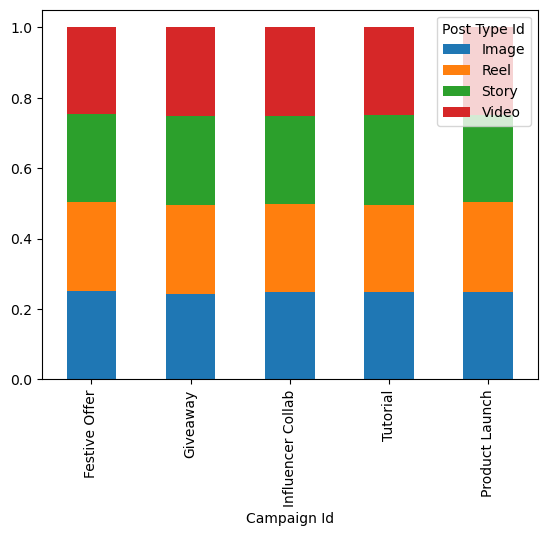

In [26]:
post_type_map = dict(zip(dim_post_type['post_type_id'], dim_post_type['post_type']))
campaign_type_map = dict(zip(dim_campaign_type['campaign_id'], dim_campaign_type['campaign_type']))

props = fact_df.groupby('Campaign Id')['Post Type Id'].value_counts(normalize = True)
wide_props = props.unstack()

wide_props.columns = wide_props.columns.map(post_type_map)
wide_props.index = wide_props.index.map(campaign_type_map)

wide_props.plot(kind = 'bar', stacked = True)
plt.show()

## <u><i> 2. Multiple Kruskal–Wallis H Tests – Examining Differences in Social Media Performance Metrics Across Content and Audience Factors <i><u>

### Null Hypothesis (H₀): There is no statistically significant difference in the distributions of Impressions, Reach, Likes, Comments, Shares, Saves, Profile Visits, or Follows across the categories of Post Type ID, Campaign ID, Emotion ID, Engagement ID, and Hashtag Counts. The distributions (or medians) of the performance metrics are equal across all groups within each categorical variable.

### Alternative Hypothesis (H₁): There is a statistically significant difference in at least one of the performance metrics (Impressions, Reach, Likes, Comments, Shares, Saves, Profile Visits, or Follows) across the categories of Post Type ID, Campaign ID, Emotion ID, Engagement ID, and Hashtag Counts. At least one group within a categorical variable exhibits a different distribution (or median) compared to the others.

In [27]:
columns = ['Post Type Id', 'Campaign Id', 'Emotion Id', 'Engagement Id', 'Hashtag Counts']
quantitative = ['Impressions', 'Reach', 'Likes', 'Comments', 'Shares', 'Saves', 'Profile Visits', 'Follows']

def  multiple_kruskal(data, dv, between):
    results = []
    for n in between:
        for m in dv: 
            output = pg.kruskal(data = data, dv = m, between = n)
            output['With'] = m            
            results.append(output)
    result = pd.concat(results, ignore_index = True)
    result['Conclusion'] = np.where(result['p_unc'] < 0.10, 'Reject', 'Fail to Reject')
    return result.sort_values(by = ['Source', 'p_unc']).reset_index(drop = True)

tests = multiple_kruskal(fact_df, quantitative, columns)
tests

,Source,ddof1,H,p_unc,With,Conclusion
0,Campaign Id,4,10.916971,0.027513,Comments,Reject
1,Campaign Id,4,7.837369,0.097721,Saves,Reject
2,Campaign Id,4,7.182541,0.126551,Likes,Fail to Reject
3,Campaign Id,4,6.728903,0.150927,Impressions,Fail to Reject
4,Campaign Id,4,6.298110,0.177964,Reach,Fail to Reject
5,Campaign Id,4,5.114239,0.275775,Shares,Fail to Reject
6,Campaign Id,4,3.477215,0.481351,Follows,Fail to Reject
7,Campaign Id,4,2.429540,0.657296,Profile Visits,Fail to Reject
8,Emotion Id,4,5.724117,0.220720,Reach,Fail to Reject
9,Emotion Id,4,4.679847,0.321752,Impressions,Fail to Reject


## <U> Conclusion: Multiple Kruskal–Wallis H Tests on Social Media Performance Metrics <U>

### A series of Kruskal–Wallis H tests were conducted to evaluate whether key social media performance metrics (Impressions, Reach, Likes, Comments, Shares, Saves, Profile Visits, and Follows) differed significantly across Post Type ID, Campaign ID, Emotion ID, Engagement ID, and Hashtag Count categories.

## <b> Campaign ID <b>

### Campaign type exhibited statistically significant differences for Comments (H = 10.917, p = 0.028) and Saves (H = 7.837, p = 0.098). However, no significant differences were observed for Likes, Impressions, Reach, Shares, Follows, or Profile Visits. These findings suggest that campaign strategies may influence audience interaction and content retention, but have limited impact on overall visibility and conversion metrics.

## <b> Emotion ID <b>

### No statistically significant differences were found across any performance metric for Emotion ID. This suggests that the emotional category associated with a post did not substantially influence social media performance within the dataset.

## <b> Engagement ID <b>

### Engagement source/type demonstrated significant differences for Impressions (H = 8.611, p = 0.035) and Reach (H = 6.660, p = 0.084). No significant differences were detected for Likes, Comments, Shares, Saves, Profile Visits, or Follows. These results indicate that engagement source may affect content visibility and distribution, but not necessarily user interactions.

## <b> Hashtag Counts <b>

### Hashtag count emerged as the most influential factor in the analysis. Significant differences were observed for Saves (H = 13.261, p = 0.001), Likes (H = 12.462, p = 0.002), Comments (H = 11.599, p = 0.003), Reach (H = 8.256, p = 0.016), Impressions (H = 8.050, p = 0.018), Shares (H = 7.984, p = 0.018), and Profile Visits (H = 5.693, p = 0.058). Only Follows did not differ significantly across hashtag count categories. These findings suggest that hashtag usage plays a substantial role in driving both visibility and engagement-related outcomes.

## <b> Post Type ID <b>

### No statistically significant differences were found across any of the performance metrics for Post Type ID. This indicates that the format of the content alone (e.g., post type) was not a major determinant of social media performance within the analyzed dataset.

## <b> Overall Findings <b>

### Among all factors examined, Hashtag Count demonstrated the strongest and most consistent relationship with social media performance metrics, affecting nearly every visibility and engagement measure. Campaign ID showed a moderate influence on audience interaction metrics such as Comments and Saves, while Engagement ID influenced visibility metrics such as Reach and Impressions. In contrast, Emotion ID and Post Type ID showed little evidence of affecting performance outcomes.

### These results suggest that hashtag strategy is likely a more important driver of social media performance than content format or emotional classification within this dataset.


## 2.1 Pair-Wise Tests for the Rejected Ones

In [28]:
pg.pairwise_tests(data = fact_df, dv = 'Comments', between = 'Campaign Id', padjust = 'bonf')

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p_unc,p_corr,p_adjust,BF10,hedges
0,Campaign Id,1,2,False,True,-1.901710,19984.664864,two-sided,0.057223,0.572235,bonf,0.097,-0.026901
1,Campaign Id,1,3,False,True,-2.980072,19868.522064,two-sided,0.002885,0.028853,bonf,1.351,-0.042261
2,Campaign Id,1,4,False,True,-2.256061,20170.600840,two-sided,0.024078,0.240775,bonf,0.202,-0.031764
3,Campaign Id,1,5,False,True,-1.438808,19907.906003,two-sided,0.150221,1.000000,bonf,0.045,-0.020392
4,Campaign Id,2,3,False,True,-1.093726,19886.102665,two-sided,0.274088,1.000000,bonf,0.029,-0.015507
5,Campaign Id,2,4,False,True,-0.341551,20172.971762,two-sided,0.732692,1.000000,bonf,0.017,-0.004808
6,Campaign Id,2,5,False,True,0.460427,19918.632910,two-sided,0.645215,1.000000,bonf,0.018,0.006524
7,Campaign Id,3,4,False,True,0.762089,20043.442994,two-sided,0.446016,1.000000,bonf,0.021,0.010757
8,Campaign Id,3,5,False,True,1.549084,19815.116226,two-sided,0.121377,1.000000,bonf,0.053,0.022003
9,Campaign Id,4,5,False,True,0.804603,20093.986282,two-sided,0.421058,1.000000,bonf,0.022,0.011348


## <u> Post-Hoc Pairwise Comparisons: Comments Across Campaign Types <u>

### Following the significant Kruskal–Wallis test result for Comments across Campaign ID categories, Bonferroni-adjusted pairwise comparisons were conducted to identify which campaign groups differed significantly.

### The analysis revealed a statistically significant difference between Campaign ID 1 and Campaign ID 3 (adjusted p = 0.029). No other pairwise comparisons remained statistically significant after applying the Bonferroni correction.

### These findings indicate that the overall difference in comment activity observed across campaign types was primarily driven by the difference between Campaign ID 1 and Campaign ID 3. The remaining campaign categories exhibited comparable comment distributions.


In [29]:
pg.pairwise_tests(data = fact_df, dv = 'Saves', between = 'Campaign Id', padjust = 'bonf')

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p_unc,p_corr,p_adjust,BF10,hedges
0,Campaign Id,1,2,False,True,-0.397922,19985.844408,two-sided,0.690692,1.000000,bonf,0.017,-0.005629
1,Campaign Id,1,3,False,True,-2.191440,19884.729695,two-sided,0.028432,0.284315,bonf,0.176,-0.031075
2,Campaign Id,1,4,False,True,-1.706935,20170.679268,two-sided,0.087849,0.878495,bonf,0.068,-0.024033
3,Campaign Id,1,5,False,True,-1.350904,19907.629375,two-sided,0.176741,1.000000,bonf,0.04,-0.019146
4,Campaign Id,2,3,False,True,-1.798778,19890.602321,two-sided,0.072069,0.720690,bonf,0.081,-0.025502
5,Campaign Id,2,4,False,True,-1.310437,20179.965594,two-sided,0.190063,1.000000,bonf,0.037,-0.018446
6,Campaign Id,2,5,False,True,-0.956509,19914.027416,two-sided,0.338827,1.000000,bonf,0.025,-0.013554
7,Campaign Id,3,4,False,True,0.499365,20068.221851,two-sided,0.617527,1.000000,bonf,0.018,0.007047
8,Campaign Id,3,5,False,True,0.839064,19823.553490,two-sided,0.401444,1.000000,bonf,0.023,0.011918
9,Campaign Id,4,5,False,True,0.345670,20093.579615,two-sided,0.729594,1.000000,bonf,0.017,0.004875


## <u> Post-Hoc Pairwise Comparisons: Saves Across Campaign Types <u>

### Following the significant Kruskal–Wallis test result for Saves across Campaign ID categories, Bonferroni-adjusted pairwise comparisons were conducted to identify specific group differences.

### The pairwise analysis did not reveal any statistically significant differences between individual campaign categories after applying the Bonferroni correction. Although the overall Kruskal–Wallis test suggested that save activity varied across campaign types, no single campaign pair exhibited a sufficiently large difference to remain significant after adjusting for multiple comparisons.

### These findings suggest that the observed overall variation in saves may be distributed across several campaign categories rather than being driven by a specific pair of campaigns.

In [30]:
pg.pairwise_tests(data = fact_df, dv = 'Impressions', between = 'Engagement Id', padjust = 'bonf')

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p_unc,p_corr,p_adjust,BF10,hedges
0,Engagement Id,1,2,False,True,2.188082,25006.976273,two-sided,0.028673,0.172037,bonf,0.156,0.027671
1,Engagement Id,1,3,False,True,2.145172,25137.248291,two-sided,0.031949,0.191692,bonf,0.142,0.027058
2,Engagement Id,1,4,False,True,2.697162,24862.446875,two-sided,0.006998,0.041988,bonf,0.542,0.034207
3,Engagement Id,2,3,False,True,-0.045256,25130.633602,two-sided,0.963904,1.000000,bonf,0.014,-0.000571
4,Engagement Id,2,4,False,True,0.512817,24855.041042,two-sided,0.608084,1.000000,bonf,0.016,0.006505
5,Engagement Id,3,4,False,True,0.558544,24982.401548,two-sided,0.576478,1.000000,bonf,0.017,0.007066


## <u>Post-Hoc Pairwise Comparisons: Impressions Across Engagement Categories <u>

### Following the significant Kruskal–Wallis test result for Impressions across Engagement ID categories, Bonferroni-adjusted pairwise comparisons were conducted to identify specific group differences.

### The analysis revealed a statistically significant difference between Engagement ID 1 and Engagement ID 4 (adjusted p = 0.042). No significant differences were observed between any other engagement category pairs after applying the Bonferroni correction.

### These findings indicate that the overall variation in impressions across engagement categories was primarily driven by the difference between Engagement ID 1 and Engagement ID 4. However, the associated effect size was very small (Hedges' g = 0.034), suggesting that the practical magnitude of the difference is limited despite its statistical significance.

In [31]:
pg.pairwise_tests(data = fact_df, dv = 'Reach', between = 'Engagement Id', padjust = 'bonf')

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p_unc,p_corr,p_adjust,BF10,hedges
0,Engagement Id,1,2,False,True,1.892022,25006.999316,two-sided,0.058500,0.350998,bonf,0.085,0.023927
1,Engagement Id,1,3,False,True,1.844758,25137.046885,two-sided,0.065084,0.390507,bonf,0.078,0.023268
2,Engagement Id,1,4,False,True,2.470169,24863.323960,two-sided,0.013512,0.081070,bonf,0.302,0.031328
3,Engagement Id,2,3,False,True,-0.050789,25129.973467,two-sided,0.959494,1.000000,bonf,0.014,-0.000641
4,Engagement Id,2,4,False,True,0.577514,24856.366345,two-sided,0.563597,1.000000,bonf,0.017,0.007325
5,Engagement Id,3,4,False,True,0.629397,24984.082507,two-sided,0.529095,1.000000,bonf,0.017,0.007962


## <U>Post-Hoc Pairwise Comparisons: Reach Across Engagement Categories <U>

### Following the significant Kruskal–Wallis test result for Reach across Engagement ID categories, Bonferroni-adjusted pairwise comparisons were conducted to identify specific group differences.

### The analysis revealed a statistically significant difference between Engagement ID 1 and Engagement ID 4 (adjusted p = 0.081). No significant differences were observed between any other engagement category pairs after applying the Bonferroni correction.

### These findings indicate that the overall variation in reach across engagement categories was primarily driven by the difference between Engagement ID 1 and Engagement ID 4. However, the corresponding effect size was very small (Hedges' g = 0.031), suggesting that the practical magnitude of the difference is limited despite its statistical significance.


## 3. <u><i> Chi-Square Tests of Independence – Examining Relationships Among Content, Audience, and Temporal Categories <i><u>

A series of Chi-Square Tests of Independence were conducted to determine whether categorical variables within the dataset were associated with one another. The analysis examined relationships among content-related variables (Post Type ID, Campaign ID, Emotion ID, and Engagement ID) as well as temporal variables (Month, Quarter, and Day of Week).

The Chi-Square Test of Independence evaluates whether the distribution of one categorical variable differs across the categories of another variable or whether the two variables operate independently. This analysis helps identify whether content characteristics and posting patterns exhibit meaningful associations within the dataset.

### <u> Null Hypothesis (H₀) <u>

There is no statistically significant association between the categorical variables being examined. The distribution of one variable is independent of the categories of the other variable.

### <u> Alternative Hypothesis (H₁) <u>

There is a statistically significant association between the categorical variables being examined. The distribution of one variable differs across the categories of the other variable, indicating that the variables are not independent.


In [32]:
columns = ['Post Type Id', 'Campaign Id', 'Emotion Id', 'Engagement Id', 'Hashtag Counts']

from itertools import combinations
def chi2_test(data, columns):
    results = []
    for x, y in combinations(columns, 2):
        expected, observed, stats = pg.chi2_independence(data = data, x = x, y = y)
        output = stats[stats['test'] == 'pearson'].copy()
        output['variable_1'] = x
        output['variable_2'] = y
        results.append(output)

    result = pd.concat(results,ignore_index=True)
    result['Conclusion'] = np.where(result['pval'] < 0.10, 'Reject H₀', 'Fail to Reject H₀')
    return (result.sort_values('variable_1').reset_index(drop=True))

chi2_test(fact_df, columns)

,test,lambda,chi2,dof,pval,cramer,power,variable_1,variable_2,Conclusion
0,pearson,1.0,34.955797,16.0,0.004030,0.013220,0.386285,Campaign Id,Emotion Id,Reject H₀
1,pearson,1.0,13.607969,12.0,0.326440,0.009525,0.223306,Campaign Id,Engagement Id,Fail to Reject H₀
2,pearson,1.0,10.548771,8.0,0.228600,0.010271,0.312919,Campaign Id,Hashtag Counts,Fail to Reject H₀
3,pearson,1.0,12.766132,12.0,0.386266,0.009225,0.209878,Emotion Id,Engagement Id,Fail to Reject H₀
4,pearson,1.0,2.323252,8.0,0.969464,0.004820,0.093297,Emotion Id,Hashtag Counts,Fail to Reject H₀
5,pearson,1.0,3.557545,6.0,0.736299,0.005965,0.133891,Engagement Id,Hashtag Counts,Fail to Reject H₀
6,pearson,1.0,5.196156,12.0,0.951104,0.005886,0.103441,Post Type Id,Campaign Id,Fail to Reject H₀
7,pearson,1.0,9.199846,12.0,0.685773,0.007831,0.156152,Post Type Id,Emotion Id,Fail to Reject H₀
8,pearson,1.0,8.378301,9.0,0.496517,0.007474,0.162721,Post Type Id,Engagement Id,Fail to Reject H₀
9,pearson,1.0,11.171705,6.0,0.083212,0.010570,0.375299,Post Type Id,Hashtag Counts,Reject H₀


In [33]:
new = fact_df.merge(bt, on = 'Post Id', how = 'left')
new = new[['Post Type Id', 'hashtag_id']]

expected, observed, stats = pg.chi2_independence(data = new, x = 'Post Type Id', y = 'hashtag_id')
stats

,test,lambda,chi2,dof,pval,cramer,power
0,pearson,1.000000,8.377074,12.0,0.755013,0.005283,0.144598
1,cressie-read,0.666667,8.375225,12.0,0.755164,0.005283,0.144572
2,log-likelihood,0.000000,8.371623,12.0,0.755457,0.005281,0.144523
3,freeman-tukey,-0.500000,8.369007,12.0,0.755670,0.005281,0.144486
4,mod-log-likelihood,-1.000000,8.366464,12.0,0.755877,0.005280,0.144451
5,neyman,-2.000000,8.361597,12.0,0.756273,0.005278,0.144384


# <i><b> Date Time Statistical Analysis <b><i>

In [34]:
date = fact_df.merge(dim_date, on = 'Date', how = 'left')
date.head()

,Post Id,Date,Post Type Id,Campaign Id,Emotion Id,Engagement Id,Impressions,Reach,Likes,Comments,...,Saves,Profile Visits,Follows,Hashtag Counts,Engagement Rate,year,quarter,month,dow,is_weekend
0,1,2024-04-19,1,1,1,1,41908,38733,6519,646,...,261,1916,663,1,0.1965,2024,2,4,5,False
1,2,2024-04-19,2,2,1,2,30587,19460,3873,434,...,105,907,294,1,0.2441,2024,2,4,5,False
2,3,2024-04-19,2,1,2,1,3968,3146,394,25,...,39,102,24,2,0.1523,2024,2,4,5,False
3,4,2024-04-19,3,3,3,3,25621,16907,1307,237,...,33,250,100,3,0.0992,2024,2,4,5,False
4,5,2024-04-19,3,1,4,3,41546,38835,2394,424,...,228,794,153,3,0.0797,2024,2,4,5,False


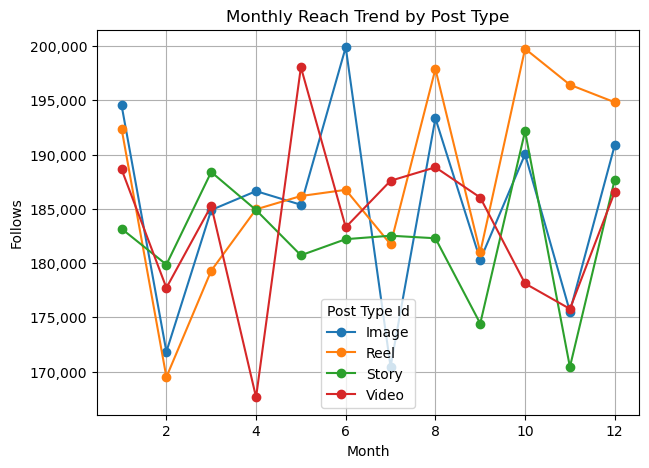

In [35]:
plot_df = (
    date.groupby(['month', 'Post Type Id'])['Follows'].sum().unstack()
)
plot_df.columns = plot_df.columns.map(post_type_map)

ax = plot_df.plot(figsize=(7,5), marker='o')

ax.ticklabel_format(style='plain', axis='y')
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
plt.xlabel('Month')
plt.ylabel('Follows')
plt.title('Monthly Reach Trend by Post Type')
plt.grid(True)
plt.show()

## 4. <u><i> Kruskal–Wallis H Tests – Examining Differences in Social Media Performance Across Temporal Factors <i><u>

A series of Kruskal–Wallis H tests were conducted to determine whether key social media performance metrics differed across temporal categories, including Quarter, Month, and Day of Week (DOW). The analysis examined the relationship between temporal variables and performance metrics such as Impressions, Reach, Likes, Comments, Shares, Saves, Profile Visits, Follows, and Engagement Rate.

The Kruskal–Wallis H test was selected because it is a non-parametric statistical test that compares the distributions of a continuous variable across three or more independent groups without requiring the assumption of normality. This makes it particularly suitable for social media performance data, which often exhibits skewness and contains outliers.

### <u> Null Hypothesis (H₀) <u>

There is no statistically significant difference in Impressions, Reach, Likes, Comments, Shares, Saves, Profile Visits, Follows, or Engagement Rate across Quarter, Month, and Day of Week categories. The distributions (or medians) of the performance metrics are equal across all temporal groups.

### <u> Alternative Hypothesis (H₁) <u>

There is a statistically significant difference in at least one of the performance metrics (Impressions, Reach, Likes, Comments, Shares, Saves, Profile Visits, Follows, or Engagement Rate) across Quarter, Month, or Day of Week categories. At least one temporal group exhibits a different distribution (or median) compared to the others.


In [36]:
columns = ['quarter', 'month', 'dow']
quantitative = ['Impressions', 'Reach', 'Likes', 'Comments', 'Shares', 'Saves', 'Profile Visits', 'Follows', 'Engagement Rate']

date_analysis = multiple_kruskal(date, quantitative, columns)
date_analysis

,Source,ddof1,H,p_unc,With,Conclusion
0,dow,6,7.226354,0.300421,Profile Visits,Fail to Reject
1,dow,6,5.248040,0.512416,Follows,Fail to Reject
2,dow,6,5.093304,0.531903,Impressions,Fail to Reject
3,dow,6,4.956869,0.549357,Shares,Fail to Reject
4,dow,6,4.860290,0.561853,Reach,Fail to Reject
5,dow,6,4.810927,0.568282,Engagement Rate,Fail to Reject
6,dow,6,4.269015,0.640322,Likes,Fail to Reject
7,dow,6,3.521850,0.741060,Comments,Fail to Reject
8,dow,6,2.873984,0.824489,Saves,Fail to Reject
9,month,11,11.076775,0.436854,Shares,Fail to Reject


### Conclusion

A series of Kruskal–Wallis H tests were conducted to determine whether social media performance metrics differed across Day of Week, Month, and Quarter categories. The analysis examined Impressions, Reach, Likes, Comments, Shares, Saves, Profile Visits, Follows, and Engagement Rate.

The results indicated that none of the performance metrics exhibited statistically significant differences across any of the temporal variables at the 10% significance level. Consequently, the null hypothesis could not be rejected for any test conducted.

These findings suggest that posting timing, whether measured by day of the week, month, or quarter, does not have a meaningful impact on content performance within the dataset. Social media performance appears to remain relatively stable throughout the year and across different days.

From a strategic perspective, these results indicate that content-related factors may play a more important role in driving engagement than posting schedules. Organizations seeking to improve performance should prioritize content optimization, campaign design, and hashtag strategy rather than focusing primarily on timing-related adjustments.


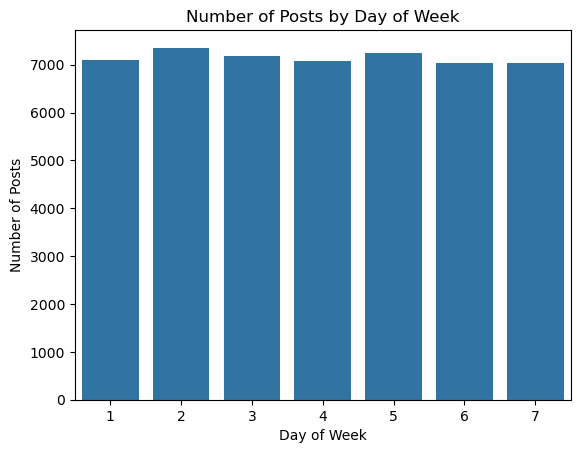

In [37]:
sns.countplot(data=date, x='dow')

plt.xlabel('Day of Week')
plt.ylabel('Number of Posts')
plt.title('Number of Posts by Day of Week')

plt.show()

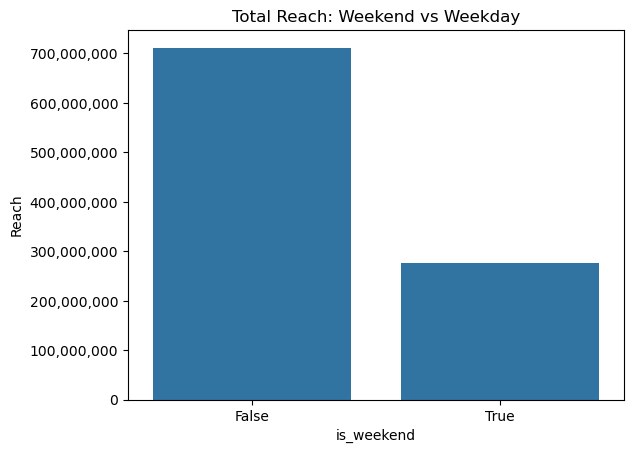

In [38]:
weekend = date.groupby('is_weekend', as_index=False)['Reach'].sum()

ax = sns.barplot(data=weekend, x='is_weekend', y='Reach')

ax.ticklabel_format(style='plain', axis='y')
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

plt.title('Total Reach: Weekend vs Weekday')
plt.show()

## 5. <u><i> Mann–Whitney U Test – Comparing Engagement Rates Between Weekday and Weekend Posts <u><i>

A Mann–Whitney U test was conducted to determine whether engagement rates differed between posts published on weekdays and those published on weekends. The analysis examined whether the timing of a post, specifically whether it was posted during the week or on the weekend, had a measurable impact on audience engagement.

The Mann–Whitney U test was selected because it is a non-parametric alternative to the independent samples t-test and does not require the assumption of normally distributed data. This makes it particularly suitable for engagement rate data, which often exhibit skewness and contain extreme values commonly observed in social media datasets.

### <u> Null Hypothesis (H₀) <u>

There is no statistically significant difference in engagement rates between weekday and weekend posts. The distribution of engagement rates is the same across both groups.

### <u> Alternative Hypothesis (H₁) <u>

There is a statistically significant difference in engagement rates between weekday and weekend posts. The distribution of engagement rates differs between the two groups.


In [39]:
weekday = date.loc[date['is_weekend'] == False, 'Engagement Rate'].reset_index(drop = True)
weekend = date.loc[date['is_weekend'] == True, 'Engagement Rate'].reset_index(drop = True)

pg.mwu(x = weekday, y = weekend)

,U_val,alternative,p_val,RBC,CLES
MWU,253472766.0,two-sided,0.569412,0.003267,0.501634


### Conclusion

A Mann–Whitney U test was conducted to determine whether engagement rates differed between weekday and weekend posts. The results indicated that there was no statistically significant difference in engagement rates between the two groups (U = 253,472,766, p = 0.569).

Since the p-value exceeded the significance threshold of 0.10, the null hypothesis could not be rejected. This suggests that posting content on weekends does not lead to significantly different engagement rates compared to posting on weekdays.

Furthermore, the effect size was negligible (Rank-Biserial Correlation = 0.003), indicating virtually no practical difference between the two groups. These findings suggest that posting day alone is unlikely to be a major driver of engagement performance, and greater emphasis should be placed on content-related factors when optimizing social media strategy.


## 6. <u><i> Mann–Whitney U Tests – Comparing Social Media Performance Metrics Between Weekday and Weekend Posts <i><u>

A series of Mann–Whitney U tests were conducted to determine whether social media performance metrics differed between posts published on weekdays and those published on weekends. The analysis examined key performance indicators, including Impressions, Reach, Likes, Comments, Shares, Saves, Profile Visits, and Follows.

The Mann–Whitney U test was selected because it is a non-parametric alternative to the independent samples t-test and does not require the assumption of normally distributed data. This makes it particularly suitable for social media performance metrics, which often exhibit skewed distributions and contain extreme values.

### <u> Null Hypothesis (H₀) <u>

There is no statistically significant difference in the distributions of Impressions, Reach, Likes, Comments, Shares, Saves, Profile Visits, or Follows between weekday and weekend posts. The distributions of these performance metrics are the same across both groups.

### <u> Alternative Hypothesis (H₁) <i>

There is a statistically significant difference in the distribution of at least one performance metric (Impressions, Reach, Likes, Comments, Shares, Saves, Profile Visits, or Follows) between weekday and weekend posts. The distributions of these performance metrics differ between the two groups.


In [40]:
quantitative = ['Impressions', 'Reach', 'Likes', 'Comments', 'Shares', 'Saves', 'Profile Visits', 'Follows']

def is_weekday_mwu(dv):
    results = []
    for i in dv:
        weekday = date.loc[date['is_weekend'] == False, i].reset_index(drop = True)
        weekend = date.loc[date['is_weekend'] == True, i].reset_index(drop = True)
        output = pg.mwu(x = weekday, y = weekend)
        results.append(output)
        output['With'] = i
    result = pd.concat(results, ignore_index = True)
    result['Conclusion'] = np.where(result['p_val'] < 0.10, 'Reject', 'Fail to Reject')
    return result.sort_values(by = ['With', 'p_val']).reset_index(drop = True)

is_weekday_mwu(quantitative)

,U_val,alternative,p_val,RBC,CLES,With,Conclusion
0,254854878.0,two-sided,0.128151,0.008738,0.504369,Comments,Fail to Reject
1,253986567.0,two-sided,0.355997,0.005301,0.502651,Follows,Fail to Reject
2,255044830.0,two-sided,0.098465,0.009490,0.504745,Impressions,Reject
3,255178684.0,two-sided,0.081056,0.010020,0.505010,Likes,Reject
4,254819559.0,two-sided,0.134369,0.008598,0.504299,Profile Visits,Fail to Reject
5,255187388.0,two-sided,0.080016,0.010054,0.505027,Reach,Reject
6,254807107.0,two-sided,0.136614,0.008549,0.504274,Saves,Fail to Reject
7,254262487.0,two-sided,0.265631,0.006393,0.503197,Shares,Fail to Reject


## <u><i>Conclusion <i><u>

A series of Mann–Whitney U tests were conducted to determine whether social media performance differed between weekday and weekend posts. The results revealed statistically significant differences in Impressions (p = 0.098), Likes (p = 0.081), and Reach (p = 0.080) at the 10% significance level.

However, no significant differences were observed for Comments, Shares, Saves, Profile Visits, or Follows. These findings suggest that posting day may influence content visibility and surface-level engagement metrics, but has limited impact on deeper audience actions.

Furthermore, the associated effect sizes were negligible across all significant metrics (Rank-Biserial Correlation ≈ 0.01), indicating that the practical impact of posting on weekends versus weekdays is minimal. Consequently, posting schedule alone does not appear to be a major determinant of overall content performance within the dataset.


## 7. <u><i>Chi-Square Tests of Independence – Examining Relationships Between Temporal Factors and Content Characteristics <i><u>

A series of Chi-Square Tests of Independence were conducted to determine whether temporal factors, including Quarter, Month, and Day of Week (DOW), were associated with key content characteristics such as Post Type ID, Campaign ID, Emotion ID, and Engagement ID.

The purpose of this analysis was to evaluate whether specific content categories were distributed differently across time periods or whether content characteristics and posting periods operated independently. Understanding these relationships can provide insights into content scheduling patterns and whether certain content types are more likely to be published during specific months, quarters, or days of the week.

### <u>Null Hypothesis (H₀) <u>

There is no statistically significant association between the temporal variables (Quarter, Month, and Day of Week) and the content characteristics (Post Type ID, Campaign ID, Emotion ID, and Engagement ID). The distribution of content categories is independent of the temporal factors being examined.

### <u>Alternative Hypothesis (H₁)<u>

There is a statistically significant association between the temporal variables (Quarter, Month, and Day of Week) and the content characteristics (Post Type ID, Campaign ID, Emotion ID, and Engagement ID). The distribution of content categories differs across one or more temporal factors, indicating that the variables are not independent.


In [41]:
date_columns = ['quarter', 'month', 'dow']
compairing = ['Post Type Id', 'Campaign Id', 'Emotion Id', 'Engagement Id']

def multiple_chisq(data, col1, col2):
    results = []
    for col in col1:
        for columns in col2:
            expected, observed, stats = pg.chi2_independence(data = data, x = col, y = columns)
            output = stats[stats['test'] == 'pearson'].copy()
            output['pairing'] = columns
            output['with'] = col
            results.append(output)
    result = pd.concat(results, ignore_index = True)
    result['conclusion'] = np.where(result['pval'] < .10, 'Reject', 'Fail to Reject')
    return result.sort_values(by = ['pairing']).reset_index(drop = True)

multiple_chisq(data = date, col1 = date_columns, col2 = compairing)

,test,lambda,chi2,dof,pval,cramer,power,pairing,with,conclusion
0,pearson,1.0,10.958108,12.0,0.532512,0.008547,0.181949,Campaign Id,quarter,Fail to Reject
1,pearson,1.0,34.419946,44.0,0.849422,0.013119,0.227389,Campaign Id,month,Fail to Reject
2,pearson,1.0,27.132284,24.0,0.298325,0.011647,0.240682,Campaign Id,dow,Fail to Reject
3,pearson,1.0,10.851264,12.0,0.541707,0.008505,0.180341,Emotion Id,quarter,Fail to Reject
4,pearson,1.0,53.379190,44.0,0.157099,0.016337,0.372378,Emotion Id,month,Fail to Reject
5,pearson,1.0,19.451984,24.0,0.727475,0.009862,0.173168,Emotion Id,dow,Fail to Reject
6,pearson,1.0,10.832695,9.0,0.287351,0.008498,0.204513,Engagement Id,quarter,Fail to Reject
7,pearson,1.0,31.868686,33.0,0.523311,0.014576,0.334002,Engagement Id,month,Fail to Reject
8,pearson,1.0,19.685776,18.0,0.350785,0.011456,0.268088,Engagement Id,dow,Fail to Reject
9,pearson,1.0,10.507532,9.0,0.310979,0.008370,0.198808,Post Type Id,quarter,Fail to Reject


## Conclusion 
Since content characteristics are distributed consistently across months, quarters, and weekdays, any significant differences observed in engagement metrics are less likely to be caused by content scheduling bias and more likely to reflect genuine differences in content performance